In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
dataset_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset")

healthy_path = dataset_path / "Healthy_Tomato"
diseased_path = dataset_path / "Diseased_Tomato"

print("Dataset folder exists:", dataset_path.exists())
print("Healthy folder exists:", healthy_path.exists())
print("Diseased folder exists:", diseased_path.exists())

Dataset folder exists: True
Healthy folder exists: True
Diseased folder exists: True


In [ ]:
print("Healthy images:")
print(os.listdir(healthy_path)[:5])

print("Diseased images:")
print(os.listdir(diseased_path)[:5])

Healthy images:
['f6a5a9a3-f9a6-4fad-83c3-2ce3e8618b52___RS_HL 0169.JPG', 'fb123526-11fd-4d0d-96cc-3423da0b61a2___RS_HL 9756.JPG', 'f62d9b06-1625-4277-9347-0f3097c41fcf___GH_HL Leaf 518.2.JPG', 'fc22b565-e97b-454d-8792-fd945d1badc5___RS_HL 9880.JPG', 'fc5c5672-d1e5-4374-bd99-608d95609a7f___RS_HL 0474.JPG']
Diseased images:
['fd6417ac-d076-4658-a4f8-6916d781c72a___RS_Erly.B 7360.JPG', 'fe856320-407c-4390-9960-a6a539371182___RS_Erly.B 7624.JPG', 'fb3352cc-9189-4214-8b94-a60c6a392c96___RS_Erly.B 9600.JPG', 'fe79c70c-0977-43f3-ad1b-3a1b4bceeceb___RS_Erly.B 7506.JPG', 'f7357222-4e77-4c46-a0ff-a17e165a70ff___RS_Erly.B 9619.JPG']


In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Your real dataset path
dataset_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset")

# Folder paths
healthy_path = dataset_path / "Healthy_Tomato"
diseased_path = dataset_path / "Diseased_Tomato"

# Get all diseased images
diseased_images = (
    list(diseased_path.glob("*.jpg")) +
    list(diseased_path.glob("*.jpeg")) +
    list(diseased_path.glob("*.png")) +
    list(diseased_path.glob("*.JPG")) +
    list(diseased_path.glob("*.JPEG")) +
    list(diseased_path.glob("*.PNG"))
)

print("Number of diseased images found:", len(diseased_images))

# Choose the first diseased image
image_path = diseased_images[0]

print("Using image:", image_path.name)

# Read the image
image = cv2.imread(str(image_path))

if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully.")
    print("Image size:", image.shape)

Number of diseased images found: 12
Using image: fd6417ac-d076-4658-a4f8-6916d781c72a___RS_Erly.B 7360.JPG
Image loaded successfully.
Image size: (256, 256, 3)


# Point 2: Preprocessing

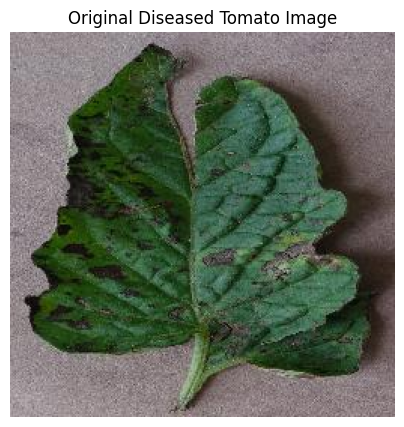

In [ ]:
# Convert image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show original image
plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title("Original Diseased Tomato Image")
plt.axis("off")
plt.show()

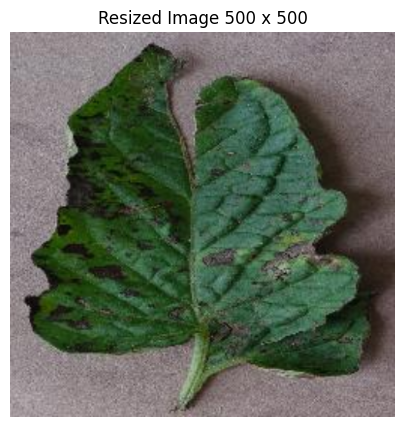

In [ ]:
# Resize image to fixed size
resized = cv2.resize(image, (500, 500))

# Convert resized image to RGB for display
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

# Show resized image
plt.figure(figsize=(5, 5))
plt.imshow(resized_rgb)
plt.title("Resized Image 500 x 500")
plt.axis("off")
plt.show()

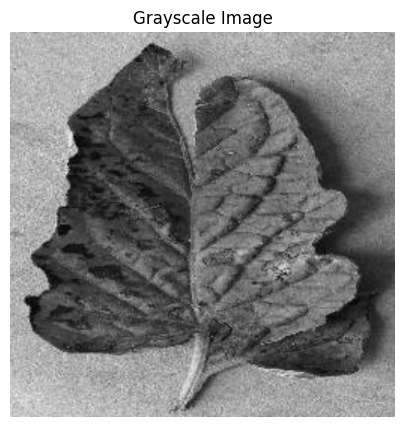

In [ ]:
# Convert resized image to grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# Show grayscale image
plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

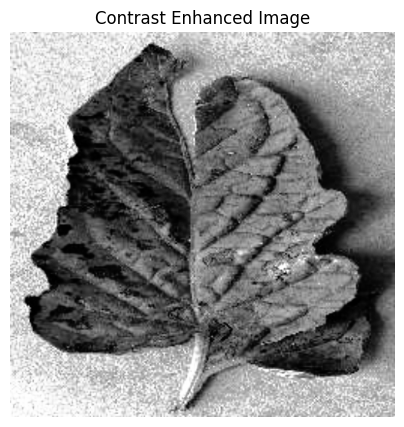

In [ ]:
# Improve contrast
contrast = cv2.equalizeHist(gray)

# Show contrast enhanced image
plt.figure(figsize=(5, 5))
plt.imshow(contrast, cmap="gray")
plt.title("Contrast Enhanced Image")
plt.axis("off")
plt.show()

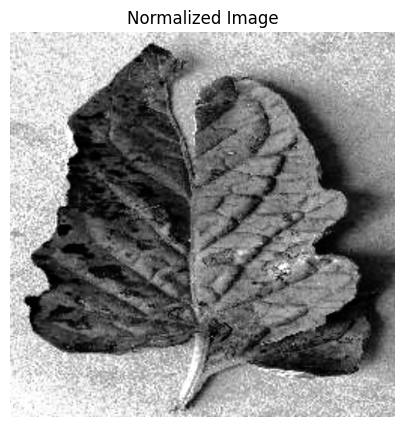

In [ ]:
# Normalize the image
normalized = cv2.normalize(contrast, None, 0, 255, cv2.NORM_MINMAX)

# Show normalized image
plt.figure(figsize=(5, 5))
plt.imshow(normalized, cmap="gray")
plt.title("Normalized Image")
plt.axis("off")
plt.show()

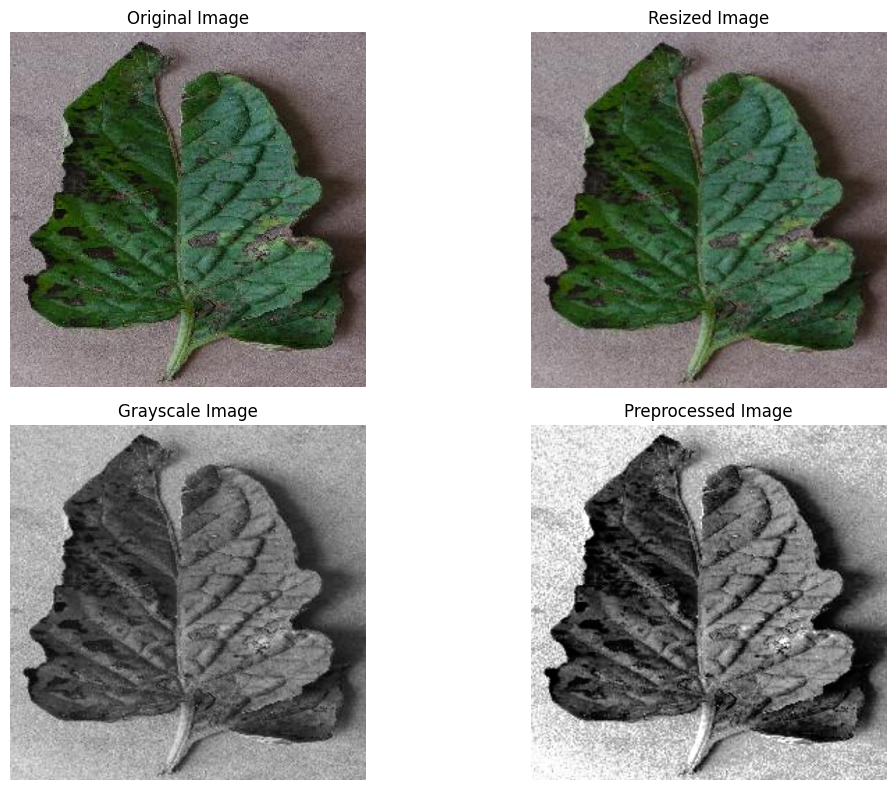

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(resized_rgb)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(normalized, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create output folder in Google Drive
output_folder = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed/Diseased_Tomato")
output_folder.mkdir(parents=True, exist_ok=True)

# Save image
save_path = output_folder / "preprocessed_diseased_tomato_01.jpg"

cv2.imwrite(str(save_path), normalized)

print("Preprocessed image saved at:")
print(save_path)

Preprocessed image saved at:
/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed/Diseased_Tomato/preprocessed_diseased_tomato_01.jpg


In [ ]:
from pathlib import Path
import cv2
import os

# Your real dataset path
dataset_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset")

# Output folder where preprocessed images will be saved
output_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed")

# Your two folders
classes = ["Healthy_Tomato", "Diseased_Tomato"]

# Image extensions to accept
extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

for class_name in classes:
    input_folder = dataset_path / class_name
    output_folder = output_path / class_name

    # Create output folder if it does not exist
    output_folder.mkdir(parents=True, exist_ok=True)

    # Get all images from the folder
    image_files = []
    for ext in extensions:
        image_files.extend(list(input_folder.glob(ext)))

    print("Processing folder:", class_name)
    print("Images found:", len(image_files))

    for image_file in image_files:
        # Read image
        image = cv2.imread(str(image_file))

        # Skip image if it cannot be opened
        if image is None:
            print("Skipped bad image:", image_file.name)
            continue

        # Step 1: Resize
        resized = cv2.resize(image, (500, 500))

        # Step 2: Convert to grayscale
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # Step 3: Improve contrast
        contrast = cv2.equalizeHist(gray)

        # Step 4: Normalize
        normalized = cv2.normalize(contrast, None, 0, 255, cv2.NORM_MINMAX)

        # Save preprocessed image
        save_name = "preprocessed_" + image_file.stem + ".jpg"
        save_path = output_folder / save_name

        cv2.imwrite(str(save_path), normalized)

    print(class_name, "completed.")
    print()

print("All images have been preprocessed successfully.")

Processing folder: Healthy_Tomato
Images found: 12
Healthy_Tomato completed.

Processing folder: Diseased_Tomato
Images found: 12
Diseased_Tomato completed.

All images have been preprocessed successfully.


In [ ]:
preprocessed_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed")

healthy_preprocessed = preprocessed_path / "Healthy_Tomato"
diseased_preprocessed = preprocessed_path / "Diseased_Tomato"

print("Preprocessed healthy images:", len(os.listdir(healthy_preprocessed)))
print("Preprocessed diseased images:", len(os.listdir(diseased_preprocessed)))

Preprocessed healthy images: 12
Preprocessed diseased images: 13


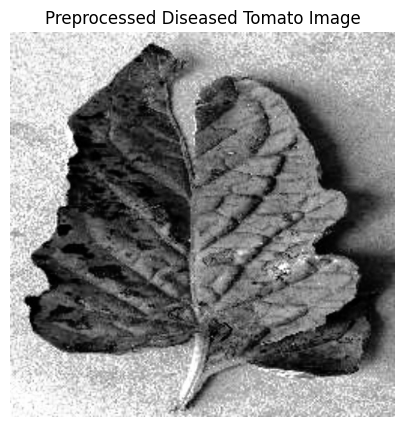

In [ ]:
import matplotlib.pyplot as plt
import cv2

sample_image_path = list(diseased_preprocessed.glob("*.jpg"))[0]

sample_image = cv2.imread(str(sample_image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")
plt.title("Preprocessed Diseased Tomato Image")
plt.axis("off")
plt.show()

#     Point 3: Image Filtering

In [ ]:
# Get all preprocessed diseased images
diseased_images = list(diseased_preprocessed.glob("*.jpg"))

print("Preprocessed diseased images found:", len(diseased_images))

# Choose first image
image_path = diseased_images[4]

print("Using image:", image_path.name)

# Read image in grayscale
image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully.")
    print("Image size:", image.shape)

Preprocessed diseased images found: 13
Using image: preprocessed_fe79c70c-0977-43f3-ad1b-3a1b4bceeceb___RS_Erly.B 7506.jpg
Image loaded successfully.
Image size: (500, 500)


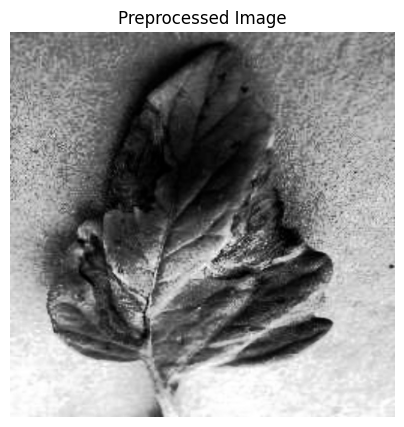

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

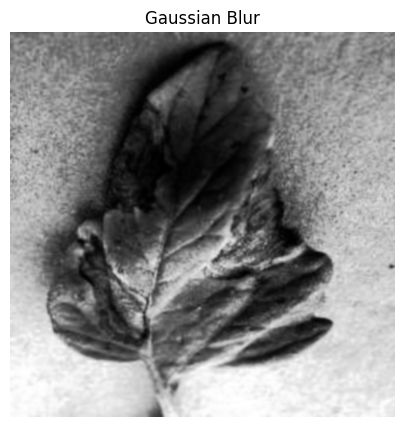

In [ ]:
gaussian = cv2.GaussianBlur(image, (5, 5), 0)

plt.figure(figsize=(5, 5))
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

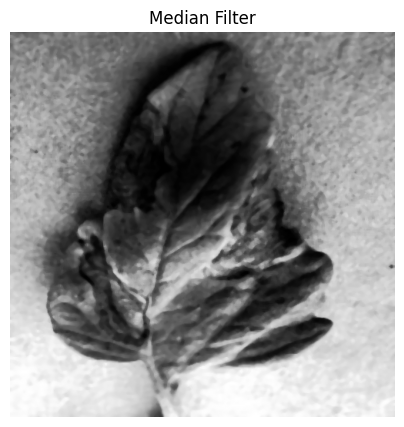

In [ ]:
median = cv2.medianBlur(image, 5)

plt.figure(figsize=(5, 5))
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")
plt.show()

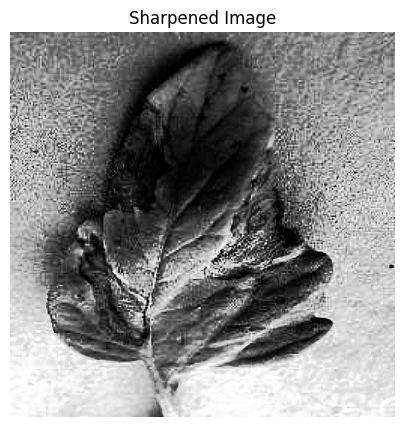

In [ ]:
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(image, -1, sharpen_kernel)

plt.figure(figsize=(5, 5))
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

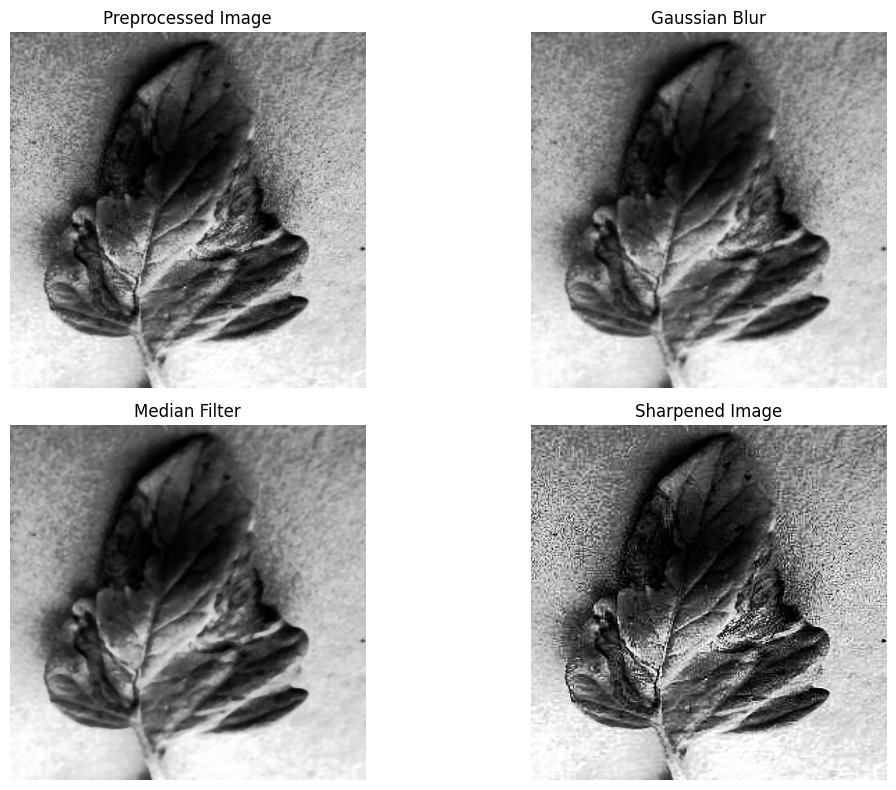

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
output_folder = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered/Diseased_Tomato")
output_folder.mkdir(parents=True, exist_ok=True)

save_path = output_folder / "filtered_diseased_tomato_01.jpg"

cv2.imwrite(str(save_path), gaussian)

print("Filtered image saved at:")
print(save_path)

Filtered image saved at:
/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered/Diseased_Tomato/filtered_diseased_tomato_01.jpg


In [ ]:
from pathlib import Path
import cv2
import os

# Input and output paths
preprocessed_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed")
filtered_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered")

classes = ["Healthy_Tomato", "Diseased_Tomato"]

for class_name in classes:
    input_folder = preprocessed_path / class_name
    output_folder = filtered_path / class_name

    output_folder.mkdir(parents=True, exist_ok=True)

    image_files = list(input_folder.glob("*.jpg"))

    print("Processing folder:", class_name)
    print("Images found:", len(image_files))

    for image_file in image_files:
        # Read preprocessed image in grayscale
        image = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped bad image:", image_file.name)
            continue

        # Apply Gaussian blur
        gaussian = cv2.GaussianBlur(image, (5, 5), 0)

        # Save filtered image
        save_name = "filtered_" + image_file.name
        save_path = output_folder / save_name

        cv2.imwrite(str(save_path), gaussian)

    print(class_name, "filtering completed.")
    print()

print("All images filtered successfully.")

Processing folder: Healthy_Tomato
Images found: 12
Healthy_Tomato filtering completed.

Processing folder: Diseased_Tomato
Images found: 13
Diseased_Tomato filtering completed.

All images filtered successfully.


In [ ]:
filtered_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered")

healthy_filtered = filtered_path / "Healthy_Tomato"
diseased_filtered = filtered_path / "Diseased_Tomato"

print("Filtered healthy images:", len(os.listdir(healthy_filtered)))
print("Filtered diseased images:", len(os.listdir(diseased_filtered)))

Filtered healthy images: 12
Filtered diseased images: 14


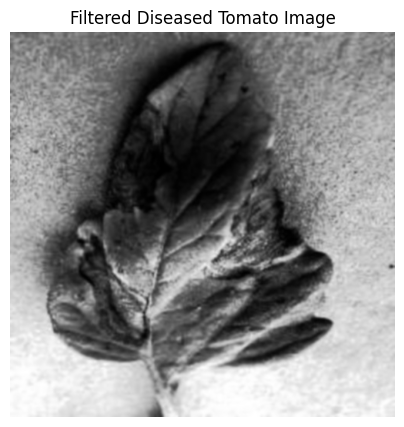

In [ ]:
sample_filtered_path = list(diseased_filtered.glob("*.jpg"))[0]

sample_filtered = cv2.imread(str(sample_filtered_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(sample_filtered, cmap="gray")
plt.title("Filtered Diseased Tomato Image")
plt.axis("off")
plt.show()

In [ ]:
from pathlib import Path
import os

dataset_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset")
preprocessed_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/preprocessed")
filtered_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered")

folders = ["Healthy_Tomato", "Diseased_Tomato"]

for folder in folders:
    dataset_folder = dataset_path / folder
    preprocessed_folder = preprocessed_path / folder
    filtered_folder = filtered_path / folder

    print(folder)
    print("Original images:", len(os.listdir(dataset_folder)))
    print("Preprocessed images:", len(os.listdir(preprocessed_folder)))
    print("Filtered images:", len(os.listdir(filtered_folder)))
    print()

Healthy_Tomato
Original images: 12
Preprocessed images: 12
Filtered images: 12

Diseased_Tomato
Original images: 12
Preprocessed images: 13
Filtered images: 14



# Point 4: Segmentation and Edge Detection

Using image: filtered_diseased_tomato_01.jpg


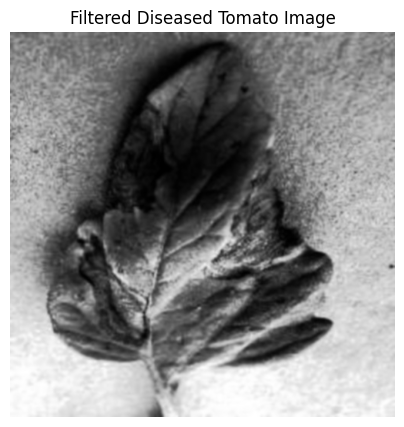

In [ ]:
filtered_images = list(diseased_filtered.glob("*.jpg"))

image_path = filtered_images[0]

print("Using image:", image_path.name)

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Filtered Diseased Tomato Image")
plt.axis("off")
plt.show()

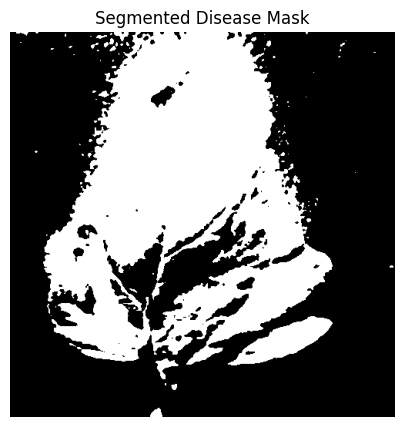

In [ ]:
_, mask = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="gray")
plt.title("Segmented Disease Mask")
plt.axis("off")
plt.show()

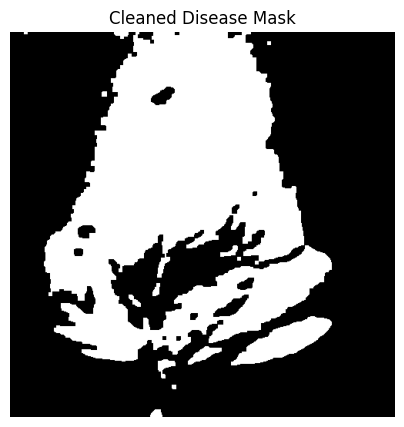

In [ ]:
kernel = np.ones((5, 5), np.uint8)

clean_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(clean_mask, cmap="gray")
plt.title("Cleaned Disease Mask")
plt.axis("off")
plt.show()

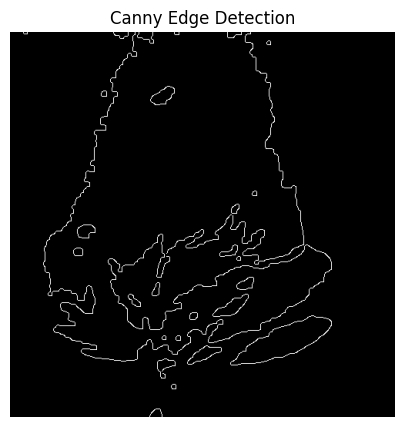

In [ ]:
edges = cv2.Canny(clean_mask, 50, 150)

plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

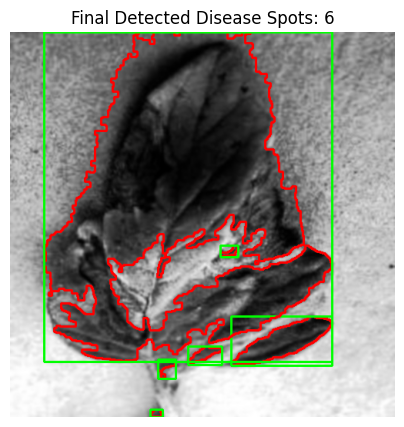

Number of detected regions: 6


In [ ]:
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

spot_count = 0

for contour in contours:
    area = cv2.contourArea(contour)

    if area > 100:
        spot_count += 1

        cv2.drawContours(output, [contour], -1, (0, 0, 255), 2)

        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(output_rgb)
plt.title(f"Final Detected Disease Spots: {spot_count}")
plt.axis("off")
plt.show()

print("Number of detected regions:", spot_count)

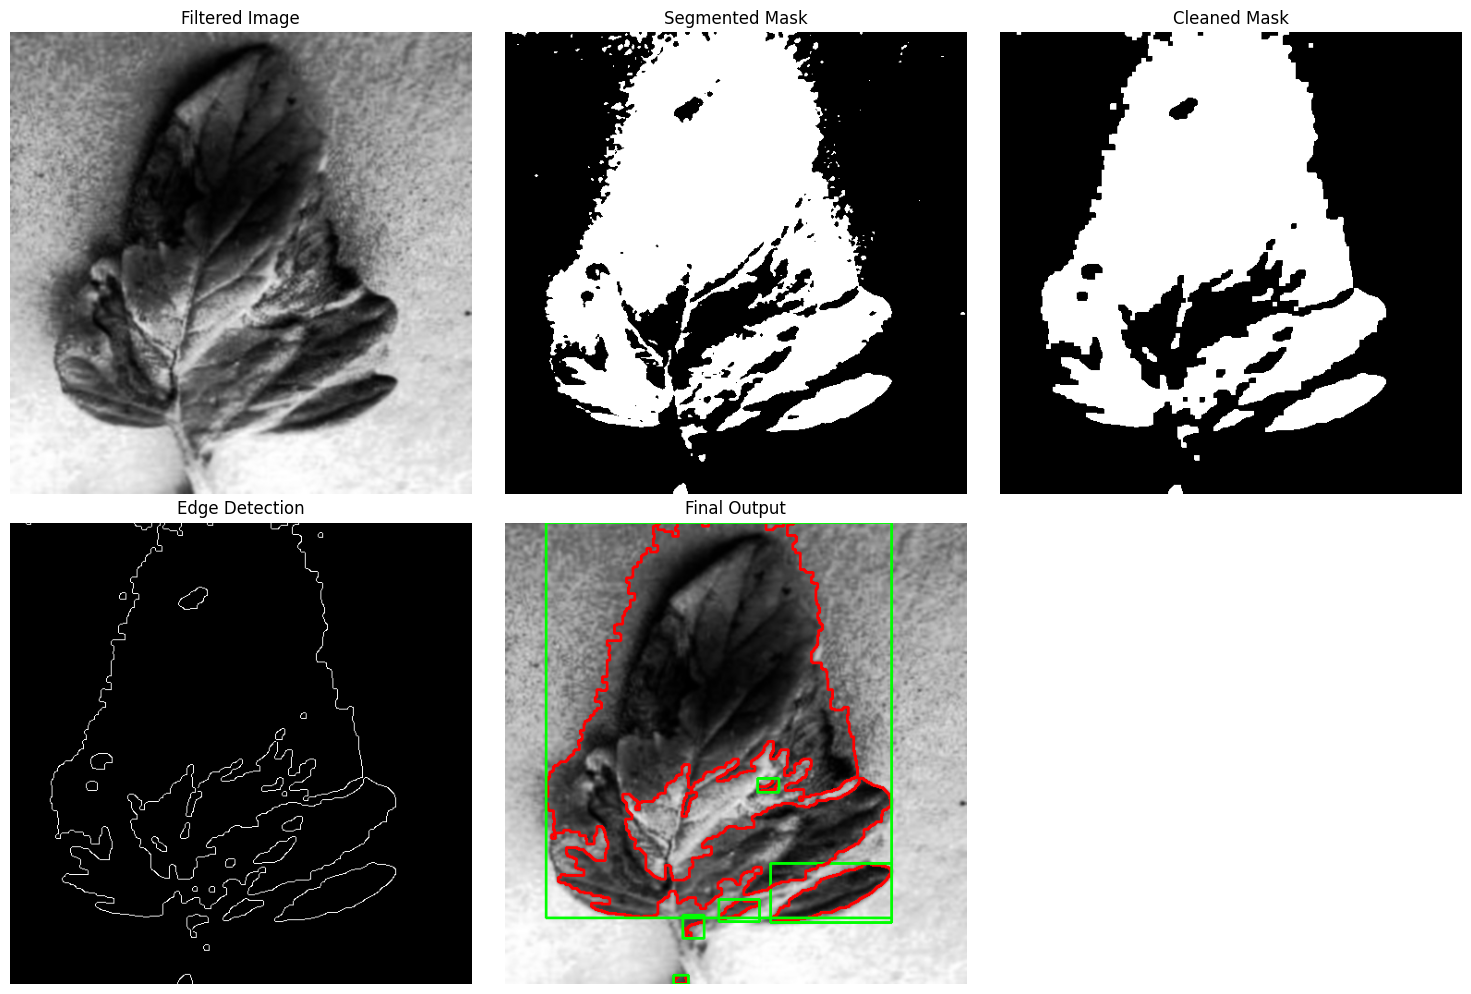

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Segmented Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(clean_mask, cmap="gray")
plt.title("Cleaned Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(output_rgb)
plt.title("Final Output")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
segmented_folder = output_base / "segmented" / "Diseased_Tomato"
edges_folder = output_base / "edges" / "Diseased_Tomato"
final_folder = output_base / "final_output" / "Diseased_Tomato"

segmented_folder.mkdir(parents=True, exist_ok=True)
edges_folder.mkdir(parents=True, exist_ok=True)
final_folder.mkdir(parents=True, exist_ok=True)

cv2.imwrite(str(segmented_folder / "segmented_diseased_tomato_01.jpg"), clean_mask)
cv2.imwrite(str(edges_folder / "edges_diseased_tomato_01.jpg"), edges)
cv2.imwrite(str(final_folder / "final_diseased_tomato_01.jpg"), output)

print("Saved segmented mask, edge image, and final output.")

Saved segmented mask, edge image, and final output.


In [ ]:
filtered_path = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/filtered")
output_base = Path("/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project")

input_folder = filtered_path / "Diseased_Tomato"

segmented_folder = output_base / "segmented" / "Diseased_Tomato"
edges_folder = output_base / "edges" / "Diseased_Tomato"
final_folder = output_base / "final_output" / "Diseased_Tomato"

segmented_folder.mkdir(parents=True, exist_ok=True)
edges_folder.mkdir(parents=True, exist_ok=True)
final_folder.mkdir(parents=True, exist_ok=True)

image_files = list(input_folder.glob("*.jpg"))

print("Diseased filtered images found:", len(image_files))

for image_file in image_files:
    image = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Skipped:", image_file.name)
        continue

    _, mask = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

    edges = cv2.Canny(clean_mask, 50, 150)

    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    for contour in contours:
        area = cv2.contourArea(contour)

        if area > 100:
            cv2.drawContours(output, [contour], -1, (0, 0, 255), 2)

            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imwrite(str(segmented_folder / ("segmented_" + image_file.name)), clean_mask)
    cv2.imwrite(str(edges_folder / ("edges_" + image_file.name)), edges)
    cv2.imwrite(str(final_folder / ("final_" + image_file.name)), output)

print("Person 4 completed for all diseased images.")

Diseased filtered images found: 14
Person 4 completed for all diseased images.


In [ ]:
print("Segmented images:", len(os.listdir(segmented_folder)))
print("Edge images:", len(os.listdir(edges_folder)))
print("Final output images:", len(os.listdir(final_folder)))

Segmented images: 15
Edge images: 15
Final output images: 15
